In [1]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/EECS545/prepare_data

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/EECS545/prepare_data


In [2]:
%ls

data/                   S1_Cheese_C1.npy  website/
embedding/              S1_Tea_C1.npy     website_files.txt
get_frame_rate.ipynb    Untitled0.ipynb   website.jsonl
groundTruth_split1.zip  video_len.json
groundTruth_split3.zip  vid_fps.json


In [3]:
import json
import os
import shutil
import numpy as np
from tqdm import tqdm
import random
import zipfile
from collections import defaultdict, Counter

import matplotlib.pyplot as plt
import seaborn as sns

SEED = 123
random.seed(SEED)

In [4]:
DATASET = "website"
EMBEDDINGS = ["i3d", "swin", "eva"]
DATA_PATH = f"data/{DATASET}"

TARGET_FPS = 30
MIN_VIDEO_LEN = 5 * TARGET_FPS
MAX_VIDEO_LEN = 50 * TARGET_FPS
MIN_FPS = 25

In [5]:
os.makedirs(f"{DATA_PATH}", exist_ok=True)
for embedding in EMBEDDINGS:
  os.makedirs(f"{DATA_PATH}/features_{embedding}", exist_ok=True)
os.makedirs(f"{DATA_PATH}/groundTruth", exist_ok=True)
os.makedirs(f"{DATA_PATH}/groundTruth_i3d", exist_ok=True)
os.makedirs(f"{DATA_PATH}/splits", exist_ok=True)

## Extracting feature information

In [6]:
# def unzip_file(zip_filepath, extract_dir):
#   with zipfile.ZipFile(zip_filepath, 'r') as zip_ref:
#     for member in zip_ref.infolist():
#       try:
#         zip_ref.extract(member, extract_dir)
#       except zipfile.error as e:
#         print(f"Error extracting {member.filename}: {e}")

In [7]:
# for embedding in EMBEDDINGS:
#   EMBEDDING_PATH = f"embedding/{embedding}"
#   for file in tqdm(os.listdir(EMBEDDING_PATH), desc=f"Extracting {embedding}:"):
#     unzip_file(f"{EMBEDDING_PATH}/{file}", f"{DATA_PATH}/features_{embedding}")

Transpose EVA features (T, C) => (C, T)

In [8]:
# EMBEDDING_PATH = f"{DATA_PATH}/features_eva"
# for file in tqdm(os.listdir(EMBEDDING_PATH), desc=f"Transposing {embedding}:"):
#     np.save(f"{EMBEDDING_PATH}/{file}", np.load(f"{EMBEDDING_PATH}/{file}").T)

## Get video info

In [9]:
if os.path.exists(f"video_len.json"):
  with open("video_len.json", 'r') as f:
    video_len = json.load(f)
else:
  video_len = {}
  for file in tqdm(os.listdir(f"{DATA_PATH}/features_swin"), desc="Fetching video info:"):
    feature = np.load(f"{DATA_PATH}/features_swin/{file}")
    video_len[file.split(".")[0]] = feature.shape[1]
  with open('video_len.json', 'w') as f:
    json.dump(video_len, f, indent=4)

In [10]:
import json
with open('video_len.json', 'w') as f:
  json.dump(video_len, f, indent=4)

In [11]:
print("Minimum video length:", min(video_len.values()))
print("Maximum video length:", max(video_len.values()))
print("Mean video length:", sum(video_len.values())/len(video_len))

# print(f"Strip video within {MIN_VIDEO_LEN} and {MAX_VIDEO_LEN}")
video_lengths = list(video_len.values())
# video_lengths = [v for v in video_lengths if v >= MIN_VIDEO_LEN and v < MAX_VIDEO_LEN]
print("Number of videos:", len(video_lengths))

Minimum video length: 1
Maximum video length: 2040
Mean video length: 455.2518014411529
Number of videos: 2498


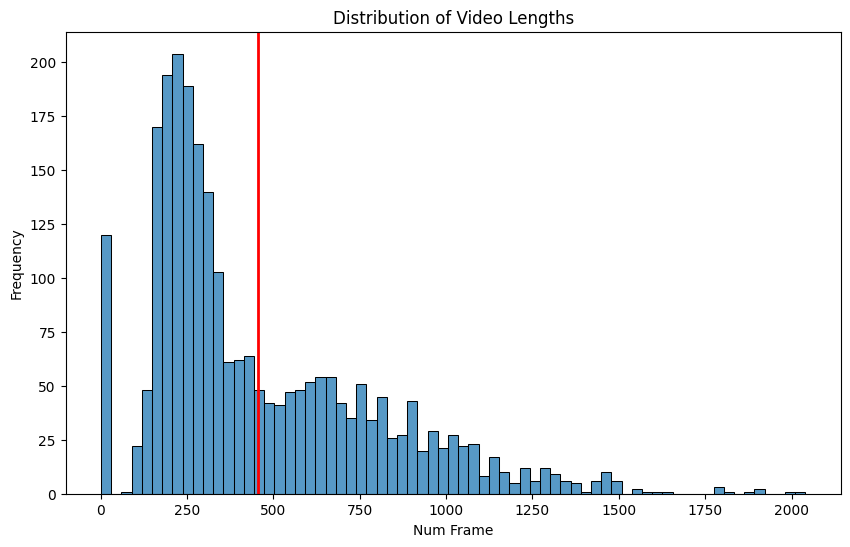

In [12]:
plt.figure(figsize=(10, 6))
sns.histplot(video_lengths, bins=max(video_len.values())//30+1)
plt.axvline(x=sum(video_len.values())/len(video_len), color='red', linestyle='-', linewidth=2)
plt.xlabel("Num Frame")
plt.ylabel("Frequency")
plt.title("Distribution of Video Lengths")
plt.show()

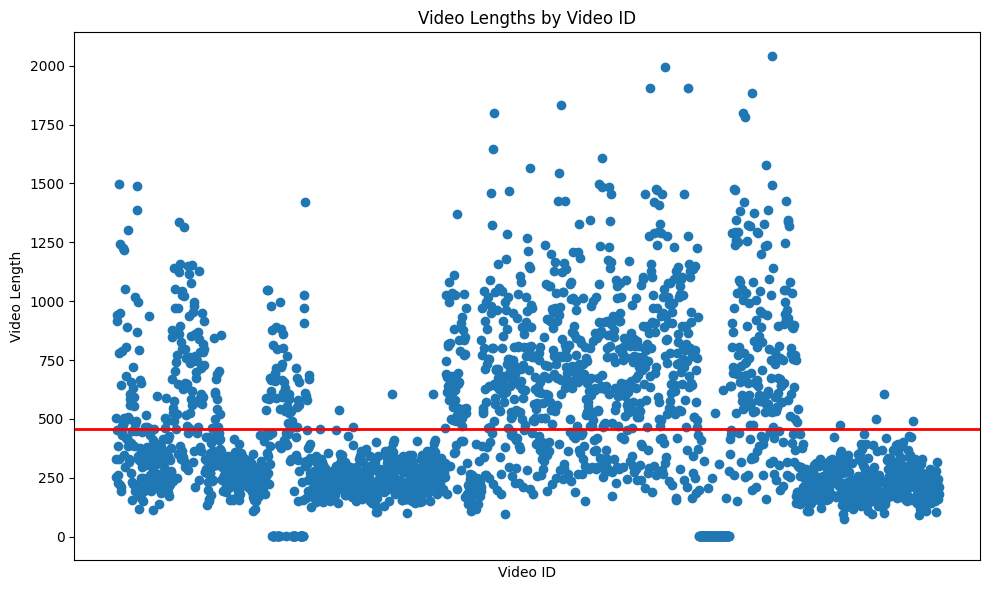

In [13]:
plt.figure(figsize=(10, 6))
plt.scatter(video_len.keys(), video_len.values())
plt.axhline(y=sum(video_len.values())/len(video_len), color='red', linestyle='-', linewidth=2)
plt.xlabel("Video ID")
plt.ylabel("Video Length")
plt.title("Video Lengths by Video ID")
plt.xticks([])
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

## Generate ground truth

Get video information

In [14]:
data = []
with open(f'{DATASET}.jsonl', 'r') as f:
  for line in f:
      data.append(json.loads(line))
with open("vid_fps.json", 'r') as f:
    vid_fps = json.load(f)

LEGTH = len(data)

Filter videos with 80~1500 and fps > 25

In [24]:
valid_video = video_len.keys()
valid_video = [video for video in valid_video if video_len[video] > MIN_VIDEO_LEN and video_len[video] < MAX_VIDEO_LEN]
valid_video = [video for video in valid_video if vid_fps[video] > MIN_FPS]
problematic_files = []
print(f"Number of videos: {len(valid_video)}")

Number of videos: 2274


In [16]:
LEGTH = len(data)
action_dict = { 'start': 0 }
action_count = defaultdict(int)
action_id_inc = 0
for i in tqdm(range(LEGTH)):
    video_id = data[i]["video_path"].split("/")[-1].split(".")[0]
    if video_id not in valid_video: continue

    fps_frac = round(vid_fps[video_id] / 30)

    with open(f"{DATA_PATH}/groundTruth/{video_id}.txt", "w") as f:
        frames = sorted(data[i]["keyframes"], key=lambda x: x["frame"])

        # The output format will be frame-wise action_ids separated by lines. For example:
            # /video1.txt
            # start
            # start
            # start
            # action_1
            # action_1
            # action_2
            # action_3

        acc = 1
        action = 'start'
        for frame in frames:
            # Print out the previous action until the current frame
            while acc < frame["frame"] / fps_frac:
                f.write(f"{action}\n")
                acc += 1

            # Get the current action
            # action = f'{frame["mouse"]}_{frame["keyboard"]}_{frame["keyboardOperation"] != ""}'
            action = f'{frame["mouse"]}_{frame["keyboard"]}'
            action_count[action] += 1

            # Add the action to the dictionary if it does not exist
            if action not in action_dict.keys():
                action_id_inc += 1
                action_dict[action] = action_id_inc

        # Print the last action_id until the end
        while acc <= video_len[video_id]:
            f.write(f"{action}\n")
            acc += 1

        if acc-1 > video_len[video_id]:
          # print(video_id, acc, video_len[video_id])
          problematic_files.append(video_id)

100%|██████████| 2253/2253 [00:18<00:00, 124.56it/s]


In [23]:
len(os.listdir(f"{DATA_PATH}/groundTruth/"))

2036

In [18]:
# Write mapping file
with open(f"{DATA_PATH}/mapping.txt", "w") as f:
    for action, id in action_dict.items():
        f.write(f"{id} {action}\n")

In [19]:
action_dict

{'start': 0,
 'drag_none': 1,
 'hover_none': 2,
 'click_none': 3,
 'none_none': 4,
 'scroll_none': 5,
 'none_input': 6,
 'none_enter': 7,
 'none_delete': 8,
 'click_enter': 9,
 'drag_input': 10,
 'click_input': 11,
 'scroll_input': 12}

In [20]:
action_count

defaultdict(int,
            {'drag_none': 258,
             'hover_none': 1597,
             'click_none': 6954,
             'none_none': 683,
             'scroll_none': 3448,
             'none_input': 154,
             'none_enter': 25,
             'none_delete': 27,
             'click_enter': 2,
             'drag_input': 1,
             'click_input': 21,
             'scroll_input': 1})

### Handle I3D ground truth

In [29]:
STRATEGY = "majority"

for file in tqdm(os.listdir(f"{DATA_PATH}/groundTruth/")):
  if video_len[file.split(".")[0]] < MIN_VIDEO_LEN: continue
  with open(f"{DATA_PATH}/groundTruth/{file}", "r") as f:
    lines = f.readlines()
    lines = [line.strip() for line in lines]

  clip_labels = []
  for i in range(0, len(lines), 8):
      clip = lines[i:i + 8]
      if not clip:
          continue
      if STRATEGY == "first":
          clip_labels.append(clip[0])
      elif STRATEGY == "majority":
          most_common = Counter(clip).most_common(1)[0][0]
          clip_labels.append(most_common)
  clip_labels = clip_labels[:-1]

  # if os.path.exists(f"{DATA_PATH}/groundTruth_i3d/{file.split('.')[0]}.npy"):
  feature = np.load(f"{DATA_PATH}/features_i3d/{file.split('.')[0]}.npy")
  # assert feature.shape[1] == len(clip_labels)
  if (feature.shape[1] != len(clip_labels)):
    # print(file, feature.shape[1], len(clip_labels))
    # clip_labels = clip_labels[:feature.shape[1]]
    problematic_files.append(file.split(".")[0])
  else:
    with open(f"{DATA_PATH}/groundTruth_i3d/{file}", "w") as f:
      for label in clip_labels:
        f.write(f"{label}\n")

100%|██████████| 2036/2036 [10:23<00:00,  3.27it/s]


## Train-Test Split

Here we use 5 non-overlapping splits

In [28]:
# Plain split
NUM_SPLIT = 5
TRAIN_TEST_SPLIT = 0.8

dataset = list(os.listdir(f"{DATA_PATH}/features_swin"))
dataset = [d for d in dataset if d.split(".")[1] == "npy" and os.path.isfile(f"{DATA_PATH}/groundTruth/{d.split('.')[0]}.txt")]
dataset = [d for d in dataset if video_len[d.split(".")[0]] >= MIN_VIDEO_LEN and video_len[d.split(".")[0]] < MAX_VIDEO_LEN and vid_fps[d.split(".")[0]] > MIN_FPS]
dataset = [d for d in dataset if d.split(".")[0] not in problematic_files]
print(f"Splitting {len(dataset)} videos into {NUM_SPLIT} splits with train-test ratio {TRAIN_TEST_SPLIT}")

random.seed(SEED)
random.shuffle(dataset)
os.makedirs(f"{DATA_PATH}/splits", exist_ok=True)
DATASET_LEN = len(dataset)
SPLIT_LEN = DATASET_LEN // NUM_SPLIT

train_split = {}
test_split = {}

for split_idx in range(NUM_SPLIT):
    start_idx = split_idx * SPLIT_LEN
    if split_idx == NUM_SPLIT - 1:
      split_dataset = dataset[start_idx:]
    else:
      split_dataset = dataset[start_idx:start_idx + SPLIT_LEN]
    TRAIN_IDX = int(TRAIN_TEST_SPLIT * len(split_dataset))
    train, test = split_dataset[:TRAIN_IDX], split_dataset[TRAIN_IDX:]
    train_split[split_idx + 1] = train
    test_split[split_idx + 1] = test

    print(f"Generating split {split_idx + 1}: train {len(train)}, test {len(test)}")

    with open(f"{DATA_PATH}/splits/train.split{split_idx + 1}.bundle", "w") as f:
        for file in train:
            f.write(f"{file.split('.')[0]}.txt\n")
    with open(f"{DATA_PATH}/splits/test.split{split_idx + 1}.bundle", "w") as f:
        for file in test:
            f.write(f"{file.split('.')[0]}.txt\n")

Splitting 2036 videos into 5 splits with train-test ratio 0.8
Generating split 1: train 325, test 82
Generating split 2: train 325, test 82
Generating split 3: train 325, test 82
Generating split 4: train 325, test 82
Generating split 5: train 326, test 82


### (Optional) KFold dataset split

In [30]:
# from sklearn.model_selection import KFold
# NUM_SPLIT = 3

# dataset = list(os.listdir(f"{DATA_PATH}/features_swin"))
# dataset = [d for d in dataset if d.split(".")[1] == "npy" and os.path.isfile(f"{DATA_PATH}/groundTruth/{d.split('.')[0]}.txt")]
# dataset = [d for d in dataset if video_len[d.split(".")[0]] >= MIN_VIDEO_LEN and video_len[d.split(".")[0]] < MAX_VIDEO_LEN and vid_fps[d.split(".")[0]] > MIN_FPS]
# dataset = [d for d in dataset if d.split(".")[0] not in problematic_files]
# print(f"Splitting {len(dataset)} videos into {NUM_SPLIT}-folds")

# train_split = {}
# test_split = {}

# kf = KFold(n_splits=NUM_SPLIT, shuffle=True, random_state=SEED)
# for split_idx, (train_idx, test_idx) in enumerate(kf.split(dataset)):
#     train = [dataset[i] for i in train_idx]
#     test = [dataset[i] for i in test_idx]
#     train_split[split_idx + 1] = train
#     test_split[split_idx + 1] = test

#     print(f"Generating split {split_idx + 1}: train {len(train)}, test {len(test)}")

#     with open(f"{DATA_PATH}/splits/train.split{split_idx + 1}.bundle", "w") as f:
#         for file in train:
#             f.write(f"{file.split('.')[0]}.txt\n")
#     with open(f"{DATA_PATH}/splits/test.split{split_idx + 1}.bundle", "w") as f:
#         for file in test:
#             f.write(f"{file.split('.')[0]}.txt\n")

### Viewing split info.

In [31]:
os.listdir(f"{DATA_PATH}/splits")

['train.split1.bundle',
 'test.split1.bundle',
 'train.split2.bundle',
 'test.split2.bundle',
 'train.split3.bundle',
 'test.split3.bundle',
 'train.split4.bundle',
 'test.split4.bundle',
 'train.split5.bundle',
 'test.split5.bundle']

In [32]:
action_dict = {}
with open(f"{DATA_PATH}/mapping.txt") as f:
  lines = f.readlines()
  for lin in lines:
    cnt, action = lin.split()
    action_dict[action] = int(cnt)
action_dict

{'start': 0,
 'drag_none': 1,
 'hover_none': 2,
 'click_none': 3,
 'none_none': 4,
 'scroll_none': 5,
 'none_input': 6,
 'none_enter': 7,
 'none_delete': 8,
 'click_enter': 9,
 'drag_input': 10,
 'click_input': 11,
 'scroll_input': 12}

In [33]:
all_actions = action_dict.keys()
for split_idx in range(NUM_SPLIT):
  print(f"Information of split {split_idx + 1}")
  with open(f"{DATA_PATH}/splits/train.split{split_idx + 1}.bundle", "r") as f:
    train_files = f.readlines()
    train_files = [file.strip() for file in train_files]

  actions = set()
  for file in train_files:
    with open(f"{DATA_PATH}/groundTruth/{file}", "r") as f:
      lines = f.readlines()
      lines = [line.strip() for line in lines]
      actions.update(lines)
  print("Train:")
  print("\tNumber of actions: ", len(actions))
  print("\tMissing actions: ", all_actions - actions)

  with open(f"{DATA_PATH}/splits/test.split{split_idx + 1}.bundle", "r") as f:
    test_files = f.readlines()
    test_files = [file.strip() for file in test_files]

  actions = set()
  for file in test_files:
    with open(f"{DATA_PATH}/groundTruth/{file}", "r") as f:
      lines = f.readlines()
      lines = [line.strip() for line in lines]
      actions.update(lines)
  print("Train:")
  print("\tNumber of actions: ", len(actions))
  print("\tMissing actions: ", all_actions - actions)

  print(f"-----------------------------------------")

Information of split 1
Train:
	Number of actions:  11
	Missing actions:  {'drag_input', 'scroll_input'}
Train:
	Number of actions:  10
	Missing actions:  {'drag_input', 'click_input', 'scroll_input'}
-----------------------------------------
Information of split 2
Train:
	Number of actions:  11
	Missing actions:  {'click_enter', 'scroll_input'}
Train:
	Number of actions:  8
	Missing actions:  {'click_enter', 'drag_input', 'click_input', 'none_delete', 'scroll_input'}
-----------------------------------------
Information of split 3
Train:
	Number of actions:  10
	Missing actions:  {'click_enter', 'drag_input', 'scroll_input'}
Train:
	Number of actions:  9
	Missing actions:  {'click_enter', 'drag_input', 'click_input', 'scroll_input'}
-----------------------------------------
Information of split 4
Train:
	Number of actions:  10
	Missing actions:  {'click_enter', 'drag_input', 'scroll_input'}
Train:
	Number of actions:  9
	Missing actions:  {'click_enter', 'drag_input', 'click_input', 's

In [34]:
train_split = {}
test_split = {}
splits = os.listdir(f"{DATA_PATH}/splits")
for split in splits:
  with open(f"{DATA_PATH}/splits/{split}", "r") as f:
    files = f.readlines()
    files = [file.strip() for file in files]
  print(f"{split}: {len(files)}")
  if split.startswith("train"):
    train_split[int(split.split(".")[1].split("split")[1])] = files
  else:
    test_split[int(split.split(".")[1].split("split")[1])] = files

train.split1.bundle: 325
test.split1.bundle: 82
train.split2.bundle: 325
test.split2.bundle: 82
train.split3.bundle: 325
test.split3.bundle: 82
train.split4.bundle: 325
test.split4.bundle: 82
train.split5.bundle: 326
test.split5.bundle: 82


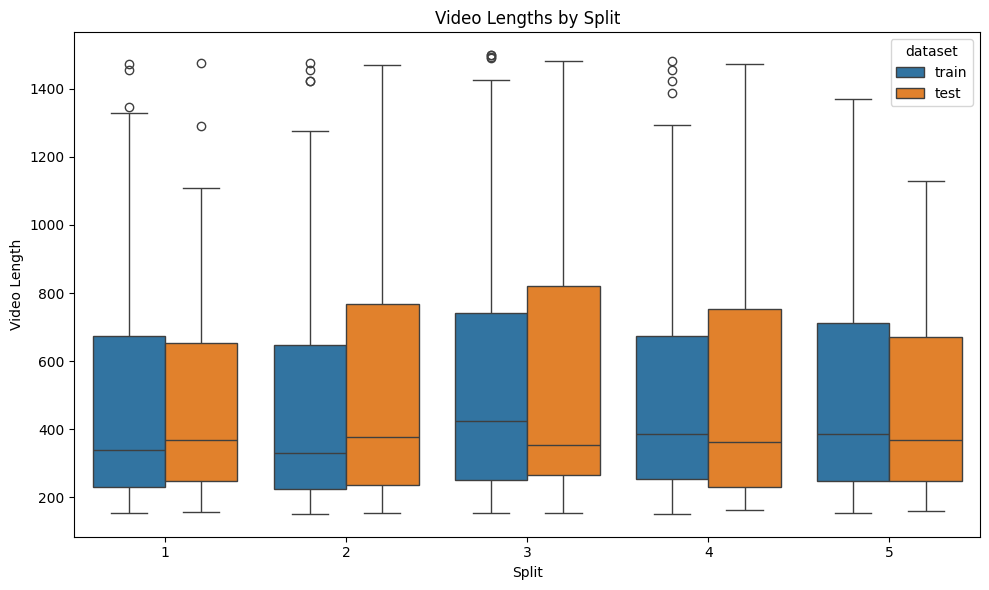

In [35]:
import pandas as pd
split_vid_len = []
for split_idx in range(NUM_SPLIT):
  for file in train_split[split_idx + 1]:
    split_vid_len.append({'dataset': 'train', 'split': split_idx + 1, 'len': video_len[file.split(".")[0]]})
  for file in test_split[split_idx + 1]:
    split_vid_len.append({'dataset': 'test', 'split': split_idx + 1, 'len': video_len[file.split(".")[0]]})
split_vid_len = pd.DataFrame(split_vid_len)

plt.figure(figsize=(10, 6))
sns.boxplot(data=split_vid_len, x="split", y="len", hue='dataset')
plt.xlabel("Split")
plt.ylabel("Video Length")
plt.title("Video Lengths by Split")
plt.tight_layout()
plt.show()

Generate toy data

In [36]:
# with open(f"{DATA_PATH}/splits/train.split1.bundle", "r") as f:
#     line = f.readlines()
#     line = [file.strip() for file in line]
# with open(f"{DATA_PATH}/splits/train.split{NUM_SPLIT + 1}.bundle", "w") as f:
#     for i in range(0, len(line), 3):
#         f.write(f"{line[i].split('.')[0]}.txt\n")

# with open(f"{DATA_PATH}/splits/test.split1.bundle", "r") as f:
#     line = f.readlines()
#     line = [file.strip() for file in line]
# with open(f"{DATA_PATH}/splits/test.split{NUM_SPLIT + 1}.bundle", "w") as f:
#     for file in line:
#         f.write(f"{file.split('.')[0]}.txt\n")

## (Optional) Zip file

In [37]:
# for split_idx in range(NUM_SPLIT):
#   for embedding in EMBEDDINGS:
#     # Define source and destination
#     source_file = f"{DATA_PATH}/features_{embedding}"
#     destination_folder = f"{DATA_PATH}/features_{embedding}_split{split_idx + 1}"

#     os.makedirs(destination_folder, exist_ok=True)
#     for file in tqdm(train_split[split_idx + 1]):
#       shutil.copy(f"{source_file}/{file.split('.')[0]}.npy", f"{destination_folder}/")
#     for file in tqdm(test_split[split_idx + 1]):
#       shutil.copy(f"{source_file}/{file.split('.')[0]}.npy", f"{destination_folder}/")
#     print(len(train_split[split_idx + 1]), len(test_split[split_idx + 1]), len(os.listdir(destination_folder)))

#     shutil.make_archive(destination_folder, 'zip', destination_folder)
#     shutil.rmtree(destination_folder)

In [38]:
# gt_file = ["", "_i3d"]
# for split_idx in range(NUM_SPLIT):
#   for gt in gt_file:
#     # Define source and destination
#     source_file = f"{DATA_PATH}/groundTruth{gt}"
#     destination_folder = f"{DATA_PATH}/groundTruth{gt}_split{split_idx + 1}"

#     os.makedirs(destination_folder, exist_ok=True)
#     for file in tqdm(train_split[split_idx + 1]):
#       shutil.copy(f"{source_file}/{file.split('.')[0]}.txt", f"{destination_folder}/")
#     for file in tqdm(test_split[split_idx + 1]):
#       shutil.copy(f"{source_file}/{file.split('.')[0]}.txt", f"{destination_folder}/")
#     print(len(train_split[split_idx + 1]), len(test_split[split_idx + 1]), len(os.listdir(destination_folder)))

#     shutil.make_archive(destination_folder, 'zip', destination_folder)
#     shutil.rmtree(destination_folder)